In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import random
import json
from google.colab import files
SEED = 900729
dir_path = './data'
train_path = './data/Training'
test_path = './data/Testing'
uploaded=files.upload()

Saving kaggle.json to kaggle.json


In [2]:
!ls
with open("kaggle.json") as f:
    kaggle_creds = json.load(f)

username = kaggle_creds["username"]
key = kaggle_creds["key"]

os.environ['KAGGLE_USERNAME'] = username
os.environ['KAGGLE_KEY'] = key

kaggle.json  sample_data


In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()


In [4]:
api.dataset_download_files("masoudnickparvar/brain-tumor-mri-dataset", path="./data", unzip=True)


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


In [5]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [6]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [7]:
tr_orginal_df = train_df(train_path)
ts_orginal_df = test_df(test_path)
ts_orginal_df


,Class Path,Class
0,./data/Testing/notumor/Te-no_0154.jpg,notumor
1,./data/Testing/notumor/Te-no_0187.jpg,notumor
2,./data/Testing/notumor/Te-no_0047.jpg,notumor
3,./data/Testing/notumor/Te-no_0341.jpg,notumor
4,./data/Testing/notumor/Te-noTr_0005.jpg,notumor
...,...,...
1306,./data/Testing/glioma/Te-gl_0136.jpg,glioma
1307,./data/Testing/glioma/Te-gl_0101.jpg,glioma
1308,./data/Testing/glioma/Te-gl_0175.jpg,glioma
1309,./data/Testing/glioma/Te-gl_0110.jpg,glioma


In [8]:
tr_orginal_df

,Class Path,Class
0,./data/Training/notumor/Tr-no_1288.jpg,notumor
1,./data/Training/notumor/Tr-no_0191.jpg,notumor
2,./data/Training/notumor/Tr-no_1348.jpg,notumor
3,./data/Training/notumor/Tr-no_0210.jpg,notumor
4,./data/Training/notumor/Tr-no_0611.jpg,notumor
...,...,...
5707,./data/Training/glioma/Tr-gl_1287.jpg,glioma
5708,./data/Training/glioma/Tr-gl_0139.jpg,glioma
5709,./data/Training/glioma/Tr-gl_0639.jpg,glioma
5710,./data/Training/glioma/Tr-gl_0257.jpg,glioma


In [9]:
val_df, tr_df = train_test_split(tr_orginal_df, train_size=0.25, random_state=SEED, stratify=tr_orginal_df['Class'])

validation_path = './data/Validation'
Path(validation_path).mkdir(exist_ok=True)

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
for class_name in classes:
    class_validation_path = Path(validation_path) / class_name
    class_validation_path.mkdir(exist_ok=True)

errors = []

for idx, row in val_df.iterrows():
    try:
        source_path = Path(row['Class Path'])

        filename = source_path.name
        class_name = row['Class']
        destination_path = Path(validation_path) / class_name / filename

        shutil.move(str(source_path), str(destination_path))

    except Exception as e:
        errors.append({
            'file': row['Class Path'],
            'class': row['Class'],
            'error': str(e)
        })


if errors:
    print(f"Errors: {len(errors)}")
    for error in errors:
        print(f"  - {error['class']}: {Path(error['file']).name} - {error['error']}")

val_df_updated = val_df.copy()
val_df_updated['Class Path'] = val_df_updated.apply(
    lambda row: str(Path(validation_path) / row['Class'] / Path(row['Class Path']).name),
    axis=1
)

tr_df_updated = train_df(train_path)

val_df = val_df_updated
tr_df = tr_df_updated

val_df

,Class Path,Class
3364,data/Validation/meningioma/Tr-me_1236.jpg,meningioma
721,data/Validation/notumor/Tr-no_0411.jpg,notumor
5526,data/Validation/glioma/Tr-gl_1169.jpg,glioma
5546,data/Validation/glioma/Tr-gl_0459.jpg,glioma
4935,data/Validation/glioma/Tr-gl_0936.jpg,glioma
...,...,...
1942,data/Validation/pituitary/Tr-pi_0024.jpg,pituitary
3899,data/Validation/meningioma/Tr-me_0457.jpg,meningioma
3138,data/Validation/meningioma/Tr-me_0294.jpg,meningioma
4272,data/Validation/meningioma/Tr-me_0233.jpg,meningioma


In [10]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import datasets
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=train_path, transform=data_transforms)
test_dataset  = datasets.ImageFolder(root=test_path, transform=data_transforms)
val_dataset   = datasets.ImageFolder(root=validation_path, transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [11]:

train_files = set(tr_df_updated['Class Path'])
val_files = set(val_df['Class Path'])

intersection = train_files.intersection(val_files)
print(f"Liczba plików, które są jednocześnie w treningu i walidacji: {len(intersection)}")

Liczba plików, które są jednocześnie w treningu i walidacji: 0


In [12]:
pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.1 MB/s eta 0:00:00


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)

unet = smp.Unet(encoder_name="efficientnet-b0", pretrained=True)
encoder = unet.encoder

class SelectLastItem(nn.Module):
    def forward(self, x):
        return x[-1]

model = nn.Sequential(
    encoder,
    SelectLastItem(),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(encoder.out_channels[-1], num_classes)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [14]:
import torch
import os

EPOCHS = 10
best_loss = float("inf")


if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth", map_location=device))
    print("Wczytano zapisany model")

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}/{EPOCHS} - Loss: {epoch_loss:.4f}")

Epoch 1/10 - Loss: 0.2477
Epoch 2/10 - Loss: 0.1159
Epoch 3/10 - Loss: 0.0801
Epoch 4/10 - Loss: 0.0701
Epoch 5/10 - Loss: 0.0629
Epoch 6/10 - Loss: 0.0477
Epoch 7/10 - Loss: 0.0555
Epoch 8/10 - Loss: 0.0209
Epoch 9/10 - Loss: 0.0227
Epoch 10/10 - Loss: 0.0204


In [15]:
model.eval()
val_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)


        val_loss += loss.item() * imgs.size(0)

        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()
val_loss = val_loss / len(val_loader.dataset)
val_accuracy = 100 * val_correct / val_total

print(f'Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.2f}%')

val_loss /= len(val_loader)
if val_loss < best_loss:
    best_loss = val_loss
    counter = 0
    torch.save(model.state_dict(), 'best_model.pth')



Validation Loss: 0.0726, Accuracy: 97.69%


Test Loss: 0.0609
Test Accuracy: 98.32%

Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.95      0.97       300
  meningioma       0.94      0.99      0.97       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311


Confusion Matrix:


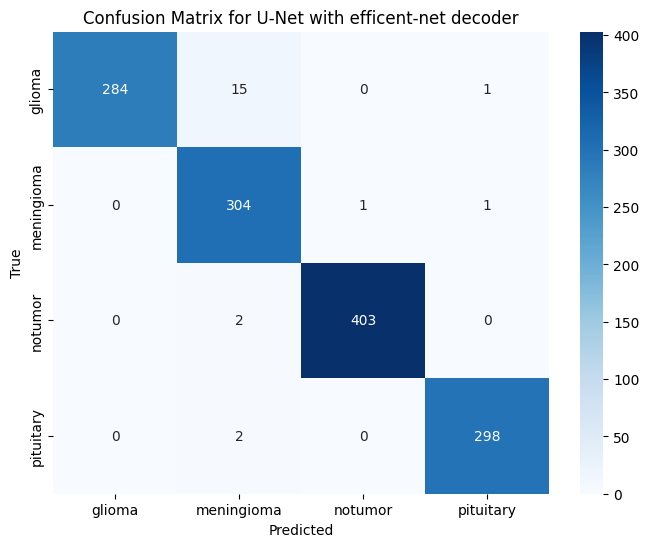

In [16]:
model.load_state_dict(torch.load('best_model.pth'))

model.eval()
test_loss = 0.0
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_loss /= len(test_loader)
accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")


print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=test_dataset.classes))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for U-Net with efficent-net decoder')
plt.show()

In [17]:
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 143.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=2af92f77fa3cb8145ca8f874168b808e1f600e20e5657ea5ec892f7fa0a0ffed
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


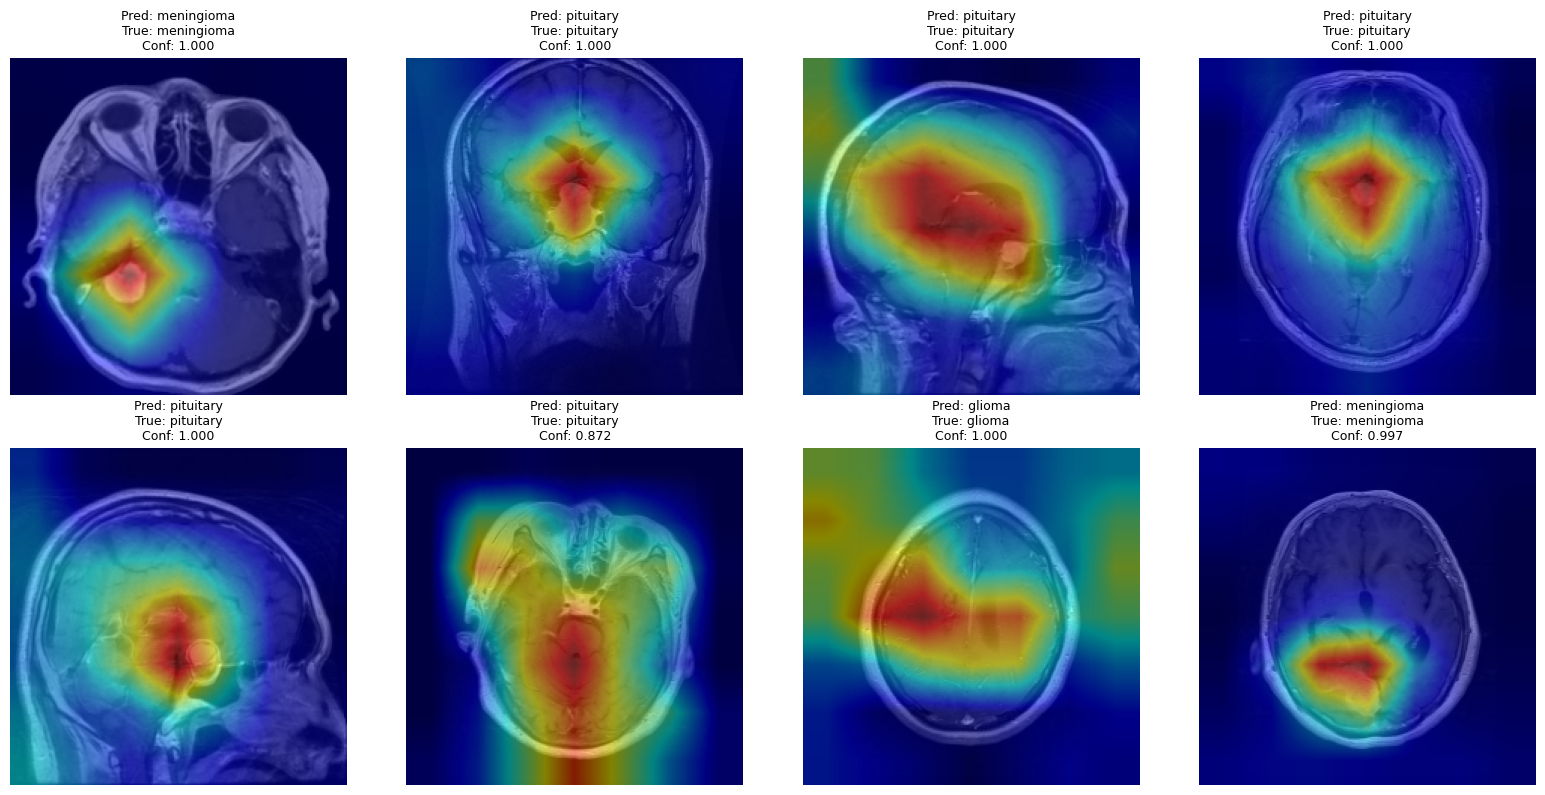

In [21]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
target_layers = [encoder._conv_head]
from pytorch_grad_cam import GradCAM
cam = GradCAM(model=model, target_layers=target_layers)

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])





target_layers = [encoder._blocks[-1]]


cam = GradCAM(model=model, target_layers=target_layers)

samples = random.sample(test_dataset.samples, 8)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (img_path, true_label) in zip(axes.flatten(), samples):

    img = cv2.imread(img_path, 1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    rgb_img = np.float32(img_resized) / 255


    input_tensor = data_transform(Image.fromarray(img_resized)).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_class = outputs.argmax(dim=1).item()
        probabilities = torch.softmax(outputs, dim=1)[0]


    targets = [ClassifierOutputTarget(predicted_class)]


    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]


    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)


    ax.imshow(visualization)
    ax.set_title(
        f"Pred: {test_dataset.classes[predicted_class]}\nTrue: {test_dataset.classes[true_label]}\nConf: {probabilities[predicted_class]:.3f}",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()